# Conformal Predictions

### **All exercises will be using your chosen dataset**

## Step 1: Import your dataset using the tutorial from the slides

## Step 2: Install necessary libraries. We will be using MAPIE for week 5

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn mapie

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from mapie.utils import train_conformalize_test_split
from mapie.classification import SplitConformalClassifier
from mapie.metrics.classification import classification_coverage_score

## Exercises

### MAPIE Docs, ML Interpretability Book, and Demo for Reference

#### [MAPIE](https://mapie.readthedocs.io/en/stable/)
#### [ML Interpretability](https://christophm.github.io/interpretable-ml-book/)
#### [Demo](https://mdst-ai-in-healthcare.streamlit.app/)


Import your **preprocessed dataset**

In [19]:
# TODO: Load your dataset with pandas
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,67.0,0,1,1,3,1,228.69,36.6,2,1
1,1.0,80.0,0,1,1,3,0,105.92,32.5,1,1
2,0.0,49.0,0,0,1,3,1,171.23,34.4,3,1
3,0.0,79.0,1,0,1,2,0,174.12,24.0,1,1
4,1.0,81.0,0,0,1,3,1,186.21,29.0,2,1


Conformal predictions are very useful for quantifying model uncertainty which provides a prediction set/interval instead of a point prediction. With a high confidence, the set/interval includes the true prediciton. For these exercises, we will be using the MAPIE library which is a very easy tool to use for creating conformal predictions. Here is a [video](https://www.youtube.com/watch?v=nql000Lu_iE) and an [article](https://arxiv.org/abs/2107.07511) which goes more in depth with conformal predictions if you are curious.

### Exercise 1: Conformal Predictions

Before getting into the predictions, we have to set a confidence level that we want to achieve.

In [20]:
# TODO: Set a desired confidence level
confidence_level = 0.9

Now you are going to train a model on your dataset and use the MAPIE split function to split the data into three sets

In [21]:
# TODO: initialize a model of your choice. Ideally, the model that had the best cross-validation score from last week
model = RandomForestClassifier(random_state=2)

In [22]:
# TODO: Set your features and target datasets
X = df[['age', 'bmi']]
y = df['stroke']

In [23]:
# TODO: Split the data into three sets(train, calibration, and testing). use train_conformalize_test_split() from MAPIE

(X_train, X_cal, X_test, y_train, y_cal, y_test) = (
    train_conformalize_test_split(
        X, y, train_size=0.8, conformalize_size=0.1, test_size=0.1, random_state=2
    )
)

In [24]:
# TODO: Optionally, calibrate the probabilities of the model again like we did in week 4 and fit the model
model_cal = CalibratedClassifierCV(estimator=model, cv=5, method='sigmoid')
model_cal.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...andom_state=2)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [25]:
# TODO: use that model and create a mapie conformal prediction model with SplitConformalClassifier(). use the prefit=True argument
mapie_model = SplitConformalClassifier(estimator=model_cal, confidence_level=confidence_level, prefit=True)

In [26]:
# TODO: 'Fit' the model using the mapie conformalize() function on the calibration data (X_cal, y_cal)
mapie_model.conformalize(X_cal, y_cal)

C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pac

In [27]:
# TODO: use predict_set() to get the point predictions and prediction sets in a tuple

y_pred, y_pred_set = mapie_model.predict_set(X_test)

y_pred is a numpy array of predicted values and y_pred_set is a numpy arrat that contains only boolean values: true for when the label is in the prediction set and false otherwise.

### Exercise 2: Model Metrics

Now, we will be evaulating the performance of the conformal predictions

In [28]:
# TODO: Use classification_coverage_score() on y_test and y_pred_set to get a coverage_score and print out the value
coverage_score = classification_coverage_score(y_test, y_pred_set)
print(coverage_score)

[0.91869919]


In [29]:
# TODO: Uncomment this line of code which creates a numpy array of set sizes

set_sizes = y_pred_set.sum(axis=1)

In [30]:
# TODO: Use the value of set_sizes above to print the average set size and the average rate of all the different set sizes possible
print(set_sizes.mean())
print(np.unique(set_sizes, return_counts=True))

0.9512195121951219
(array([0, 1]), array([ 24, 468]))


Did your model ever output an empty set and why do you think it did?

What was the effective coverage of the conformal predictions? You can think of effective coverage as the percent of predictions where the true prediction was in the prediction set. Was the confidence level that you set earlier met? If not, consider increasing the size of the calibration data.

### Visualizations

we are going to create a couple visualizations to determine the relationship between set sizes and the confidence of the model

In [31]:
# TODO: First, we need to get the max predicted probabilities (between the classes) of the model which is interpreted as the model confidence
# use predict_proba on the test data and use max(axis=1)
confidence = model_cal.predict_proba(X_test).max(axis=1)

In [32]:
# This code creates a pandas dataframe with the model confidence and set sizes
# uncomment this block and run

df = pd.DataFrame({
    "confidence": confidence,
    "set_size": set_sizes.flatten()
})

<Axes: xlabel='set_size', ylabel='confidence'>

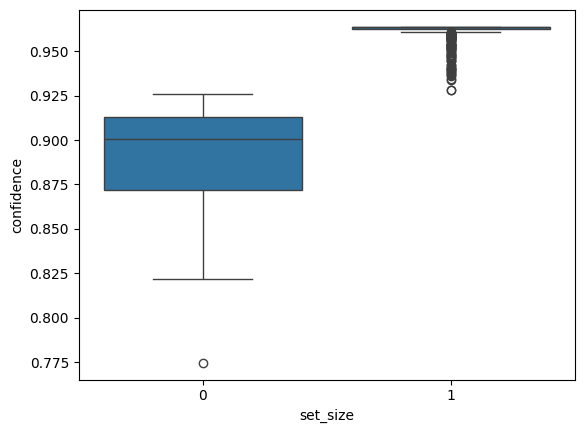

In [33]:
# TODO: Create a boxplot to find the relationship between x='confidence' and y='set_size'
sns.boxplot(data = df, x = 'set_size', y='confidence')

What are the trends between confidence and set size?

<Axes: xlabel='set_size', ylabel='confidence'>

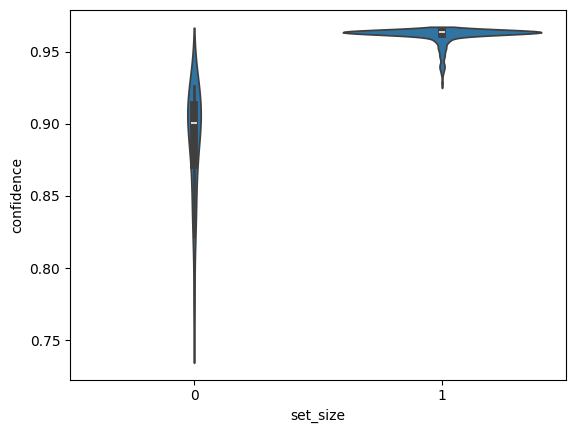

In [34]:
# TODO: Do the same thing with a violin plot
sns.violinplot(data = df, x = 'set_size', y='confidence')

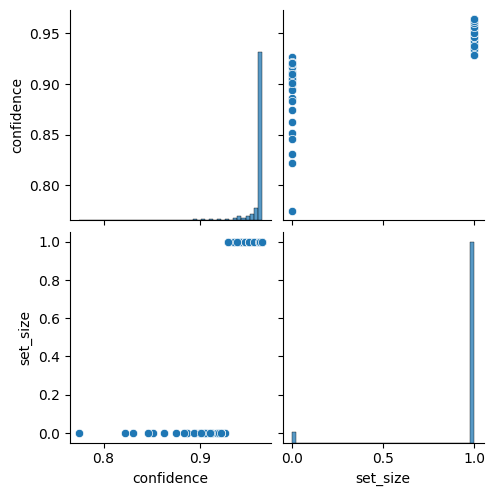

In [35]:
# TODO: Create a seaborn pairplot using the dataframe
sns.pairplot(data = df)

What final insights can you take away from these visualizations and evaluations? How can conformal predictions create a more ethical predictive model?

### Exercise 3: Git and Directory Setup

#### Step 1: Install Git and create Github account

Use this link to download [Git](https://git-scm.com/install/)

Create a Github account if you have not already done so

Create a new repository and title it whatever you want and add a README.md file

#### Step 2: Directory Setup

Clone the repository on your local machine with https using `git clone`

`cd` into the repository and use your perferred IDE/Code Editor

Create a python virtual environment by running this command in the terminal: `python -m venv env`

This command will activate the virtual environment: `source env/bin/activate`

Now, install these dependencies using pip. This should already be installed with python.

`pip install pandas numpy matplotlib seaborn scikit-learn mapie shap streamlit watchdog`

Now run, `pip freeze > requirements.txt` which creates a text file with all dependencies

#### Step 3: Installing Extensions

If you are using VSCode, make sure to install the **Python extension** by microsoft

Install the **Jupyter Notebook extension**

Now, you can start adding the notebooks that you worked on into this directory!